## A notebook to analyze groups of croparrays  

### Read in, combine, and making measurements 

In [1]:
import croparray as ca
from pathlib import Path
%gui qt

In [6]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

# Files & Directories
DATA_DIR_1 = Path(r"\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260331_HA_ZAK_HT\WT_U2OS\CropArrays")
DATA_DIR_2 = Path(r"\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\HT\CropArrays")
#DATA_DIR_3 = Path(r"\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260331_HA_ZAK_HT\NoDox\HT\CropArrays")

LABELS = ['WT','-Zak']
OUTPUT = Path(r"\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK") 

nc_files_1 = sorted(DATA_DIR_1.glob("*.nc"))
nc_files_2 = sorted(DATA_DIR_2.glob("*.nc"))
#nc_files_3 = sorted(DATA_DIR_3.glob("*.nc"))

# Measurement parameters
REF_CH = 1  # Optional reference channel for best_z_proj (if use_zc=False, i.e. when Z not tracked)
DISK_R = 7  # Radius of disk in pixels to measure signal
DISK_BG = 9 # Radius of single pixel ring around disk to measure background 
ROLL_N = 1  # Rolling z-average for signal measurement.

In [7]:
my_ca = ca.build.open_measure_concat(
    groups=[nc_files_1, nc_files_2],
    dims=["exp", "fov"],
    labels=[LABELS, None],
    measure_kwargs=dict(ref_ch=REF_CH, disk_r=DISK_R, disk_bg=DISK_BG, roll_n=ROLL_N,drop_int=True, # drop full z-stack to save memory, keeping best_z_proj
    ),
    open_as = "croparray",  # can be croparray or trackarray 
    join="outer",
)

In [8]:
# Create binary masks from "best_z" so can measure morphological properties. 
my_ca.ops.apply(
    ca.tools.binarize_crop_manual,
    channels=[1],               # Channel used to generate mask
    source="best_z",            # Image layer to threshold (typically z-projected signal)
    out_name="ch{ch}_mask",     # Output mask variable name (→ "ch0_mask")

    # Recommended parameters forwarded directly to binarize_crop_manual(...)
    func_kwargs=dict(
        q=0.45,                 # Threshold at 45% after intensity normalization
        q_range=(0.02, 0.999),  # Normalize intensities using 2%–99.9% quantile range
        q_positive_only=True,   # Ignore negative pixels (important for best_z)
        close_px=1,             # Morphological closing (bridge small gaps)
        smooth_px=0,            # Light smoothing of mask edges
        fill_holes=False,       # Do not fill internal holes
        return_uint8=True,      # Store mask as uint8 (0/1)
        morph_px=0,             # Apply a dilation of final mask (morph_pix > 0; <0 for erosion)
    ),
);

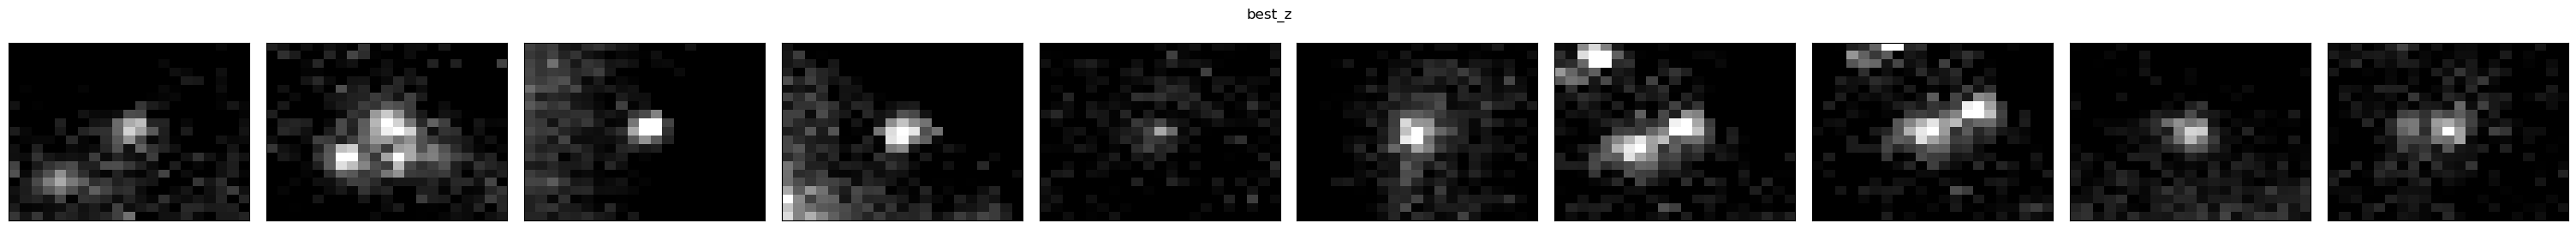

In [9]:
my_ca.isel(exp=0,fov=0,ch=1).plot.plot_croparray_crops(n=(0,10,1), layer='best_z',t=(0,1,1), col='n');

In [24]:
# Check masks with napari
viewer, layers = my_ca.isel(exp=0,fov=0).napari.montage_viewer(
    row="n",
    col="t",
    ch=1,
    show=("best_z", "ch1_mask"),
    #ch=[0, 1, 2],  # RGB
    colormaps={"ch1_mask": "magenta","best_z": "green"},
    image_contrast=[0.5,99.5],
    show_tile_text=False,
)

In [10]:
# Make measurements of desired properties 
# See https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops
my_ca.measure.mask_props(source ="ch1_mask", props=['eccentricity','major_axis_length_px','minor_axis_length_px']);

In [11]:
# =======================================
# SAVE YOUR WORK TO A NEW CROP/TRACKARRAY
# =======================================

my_file = ca.io.save_croparray(my_ca, output_dir=OUTPUT, ext='.nc')
my_file

C:\Users\tstasevi\Documents\GitHub\croparray\croparray\io.py:467: SerializationWarning: saving variable xc_pix with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_to_save.to_netcdf(str(out_path), **kwargs)
c:\Users\tstasevi\AppData\Local\anaconda3\envs\croparray_env\lib\site-packages\xarray\core\duck_array_ops.py:253: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
C:\Users\tstasevi\Documents\GitHub\croparray\croparray\io.py:467: SerializationWarning: saving variable yc_pix with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_to_save.to_netcdf(str(out_path), **kwargs)
C:\Users\tstasevi\Documents\GitHub\croparray\croparray\io.py:467: SerializationWarning: saving variable zc_pix with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_to_save.to_netcdf(str(out_path), **kwargs)
C:\Users\tstasevi\Documents\GitHub\croparray\croparray\io.py:467: Ser

WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/PB_MAX_Cell02__12exp_fov.nc')

In [12]:
# check your saved data; note concatenation history is saved
temp = ca.tools.open_croparray(my_file)
temp.ds

<xarray.Dataset> Size: 1GB
Dimensions:                         (n: 261, t: 46, y: 21, x: 21, fov: 7,
                                     exp: 2, ch: 2, z: 1)
Coordinates:
  * n                               (n) int16 522B 0 1 2 3 4 ... 257 258 259 260
  * t                               (t) int32 184B 0 1 2 3 4 ... 41 42 43 44 45
  * y                               (y) float64 168B -1.3 -1.17 ... 1.17 1.3
  * x                               (x) float64 168B -1.3 -1.17 ... 1.17 1.3
  * fov                             (fov) int32 28B 0 1 2 3 4 5 6
  * exp                             (exp) object 16B 'WT' '-Zak'
  * ch                              (ch) int32 8B 0 1
  * z                               (z) float64 8B 0.0
Data variables: (12/25)
    ch1_mask                        (exp, fov, n, t, x, y) int8 74MB ...
    xc                              (exp, fov, n, t, ch) float32 1MB ...
    yc                              (exp, fov, n, t, ch) float32 1MB ...
    zc                              (exp, fov, n, t, ch) float32 1MB ...
    xc_pix                          (exp, fov, n, t, ch) int16 672kB ...
    yc_pix                          (exp, fov, n, t, ch) int16 672kB ...
    ...                              ...
    ch1_mask__eccentricity          (exp, fov, n, t) float64 1MB ...
    ch1_mask__major_axis_length_px  (exp, fov, n, t) float64 1MB ...
    ch1_mask__minor_axis_length_px  (exp, fov, n, t) float64 1MB ...
    fov_name                        (exp, fov, n) object 29kB ...
    best_z                          (exp, fov, n, ch, t, y, x) float64 1GB ...
    signal                          (exp, fov, n, ch, t) float64 3MB ...
Attributes: (12/16)
    name:                      PB_MAX_Cell02 +11 (concat[12] exp×fov)
    date:                      2026-03-31
    xy_pad:                    10
    z_pad:                     1
    dx:                        0.13
    dy:                        0.13
    ...                        ...
    signal_units:              a.u.
    croparray_schema_version:  2.0
    notes:                     A crop array in WT U2OS cells. Imaged once eve...
    provenance_json:           {\n  "timestamp": "2026-04-05T12:45:08",\n  "d...
    concat_meta_json:          {"base_name": "PB_MAX_Cell02", "dims": ["exp",...
    filename:                  PB_MAX_Cell02__12exp_fov.nc

### Manual filtering of saved croparray

In [1]:
import croparray as ca
from pathlib import Path
%gui qt

In [2]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

INPUT_FILE = Path(r"//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260402_deltaZAK/PB_MAX_Cell02__12exp_fov.nc")

In [3]:
# Need to open this way to get proper doc strings:
from croparray.trackarray.object import CropArray
my_ca: CropArray = ca.io.open_croparray(INPUT_FILE, as_object=True)

[CropArray] Found 1 sidecar(s).
[CropArray] Checking sidecar: \\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell02__12exp_fov__manual__bad.nc
[CropArray] Merging sidecar \\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell02__12exp_fov__manual__bad.nc with vars: ['bad']
[CropArray] Merging sidecars into CropArray dataset.


In [4]:
# Quick and user-friendly manual filtering of tracks with napari 
# Create and save filter names (e.g. a 'bad' filter to remove noisy crops/tracks)
# Can also create filters like 'toi' to highlight tracks of interest  
filter_name = "bad"
viewer, layers, ft = my_ca.napari.manual_filter_montage(
    row="n",  # can be 'track_id' for trackarrays or 'n' for croparrays               
    col="t",  
    filter_name=filter_name,
    show=("best_z", "ch1_mask"),
    ch=1,
    colormaps={"ch1_mask":"magenta", "best_z":"green", filter_name:"yellow"},
    output_dir= INPUT_FILE.parent,
    show_tile_text=False, # adds layer w/ crop coords; takes memory,
    show_click_info=True, # useful for debugging
)

INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell02__12exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell02__12exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell02__12exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell02__12exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell02__12exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell02__12exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260402_deltaZAK\PB_MAX_Cell0

In [40]:
# # Test your filter:
my_ca.where(my_ca.ds[filter_name] == 0).napari.montage_viewer(row="n", col="t",show=("best_z","ch1_mask"),ch=1,show_tile_text=False)

(Viewer(camera=Camera(center=(0.0, np.float64(1448.5), np.float64(472.0)), zoom=np.float64(0.26224982746721875), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(1.0), np.float64(2.0), 0.0, 0.0), viewbox=None, scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=4, ndisplay=2, order=(0, 1, 2, 3), axis_labels=('exp', 'fov', 'y', 'x'), rollable=(True, True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(2.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(4.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(2897.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(944.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0, 0.0), 